In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import torch
import torch.nn as nn
import matplotlib.lines as mlines
import corner
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import sys
sys.path.append('../../')
import data.datasets as datasets
from models.losses import SupervisedSimCLRLoss,NPLMLoss
#from models.networks import CustomEfficientNet
from models.networks import MLP
from models.litmodels import SimCLRModel,LossCollector
import data.data_utils as dutils
from torch.utils.data import TensorDataset
from torch.utils.data import random_split
import lightning as pl
from utils.PLOTutils import plot_training_data

In [51]:
# --- Selection & Mass Calculations ---
def compute_mass(E, px, py, pz):
    return np.sqrt(np.maximum(E**2 - px**2 - py**2 - pz**2, 0))

def compute_pair_mass(e1, px1, py1, pz1, e2, px2, py2, pz2):
    E = e1 + e2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    return np.sqrt(np.maximum(E**2 - px**2 - py**2 - pz**2, 0))

def compute_m4l(E, px, py, pz):
    E_tot = np.sum(E, axis=1)
    px_tot = np.sum(px, axis=1)
    py_tot = np.sum(py, axis=1)
    pz_tot = np.sum(pz, axis=1)
    return np.sqrt(np.maximum(E_tot**2 - px_tot**2 - py_tot**2 - pz_tot**2, 0))


def compute_pt(px, py):
    px_tot = np.sum(px, axis=1)
    py_tot = np.sum(py, axis=1)
    return np.sqrt(px**2 + py**2)

def has_ossf(row):
    leptons = [row[f'PID{i}'] for i in range(1, 5)]
    for i, j in combinations(range(4), 2):
        pid_i = leptons[i]
        pid_j = leptons[j]
        # Same flavor (abs equal), opposite sign
        if abs(pid_i) == abs(pid_j) and pid_i * pid_j < 0:
            return True
    return False

def has_z_candidate(row):
    for i, j in combinations(range(1, 5), 2):
        pid_i = row[f'PID{i}']
        pid_j = row[f'PID{j}']
        if abs(pid_i) == abs(pid_j) and pid_i * pid_j < 0:
            mll = compute_pair_mass(
                row[f'E{i}'], row[f'px{i}'], row[f'py{i}'], row[f'pz{i}'],
                row[f'E{j}'], row[f'px{j}'], row[f'py{j}'], row[f'pz{j}']
            )
            if 60 < mll < 120:
                return True
    return False

def select_higgs_candidates(df):
    E  = df[['E1', 'E2', 'E3', 'E4']].values
    px = df[['px1', 'px2', 'px3', 'px4']].values
    py = df[['py1', 'py2', 'py3', 'py4']].values
    pz = df[['pz1', 'pz2', 'pz3', 'pz4']].values
    df['m4l'] = compute_m4l(E, px, py, pz)
    
    df = df[df.apply(has_ossf, axis=1)]
    df = df[df.apply(has_z_candidate, axis=1)]
    df = df[(df['m4l'] > 70) & (df['m4l'] < 180)]
    return df


def pt(px, py):
    return np.sqrt(px**2 + py**2)

def find_ossf_pairs(row):
    """Find all OSSF lepton pairs. Return list of (i, j) indices."""
    pairs = []
    for i, j in combinations(range(1, 5), 2):
        pid_i = row[f'PID{i}']
        pid_j = row[f'PID{j}']
        if abs(pid_i) == abs(pid_j) and pid_i * pid_j < 0:
            pairs.append((i, j))
    return pairs

def select_higgs_candidates(df):
    # Invariant mass
    E = df[[f'E{i}' for i in range(1, 5)]].values
    px = df[[f'px{i}' for i in range(1, 5)]].values
    py = df[[f'py{i}' for i in range(1, 5)]].values
    pz = df[[f'pz{i}' for i in range(1, 5)]].values
    df['m4l'] = compute_m4l(E, px, py, pz)

    selected_rows = []

    for idx, row in df.iterrows():
        ossf_pairs = find_ossf_pairs(row)

        # Require ≥2 OSSF pairs
        if len(ossf_pairs) < 2:
            continue

        # Compute invariant masses for all OSSF pairs
        pair_masses = []
        for i, j in ossf_pairs:
            mll = compute_pair_mass(
                row[f'E{i}'], row[f'px{i}'], row[f'py{i}'], row[f'pz{i}'],
                row[f'E{j}'], row[f'px{j}'], row[f'py{j}'], row[f'pz{j}']
            )
            pair_masses.append(((i, j), mll))

        # Sort to find Z1 (closest to Z mass)
        pair_masses.sort(key=lambda x: abs(x[1] - 91.2))
        (i1, j1), mZ1 = pair_masses[0]
        used_indices = {i1, j1}

        # Find next OSSF pair not overlapping Z1
        mZ2 = None
        for (i, j), mass in pair_masses[1:]:
            if i not in used_indices and j not in used_indices:
                mZ2 = mass
                break

        if mZ2 is None:
            continue

        # ChatGPT (loose mode)
        #if not (70 < mZ1 < 110):
        #    continue
        #if not (4 < mZ2 < 120):
        #    continue

        #CMS
        if not (50 < mZ1 < 120):
            continue
        if not (12 < mZ2 < 120):
            continue

        # Loosened lepton pT cuts
        pts = [pt(row[f'px{i}'], row[f'py{i}']) for i in range(1, 5)]
        pts.sort(reverse=True)
        #if not (pts[0] > 10 and pts[1] > 5 and pts[2] > 5 and pts[3] > 5): #ChatGPT (Loose mode)
        if not (pts[0] > 20 and pts[1] > 10 and pts[2] > 5 and pts[3] > 5): #CMS
            continue
        
        # 4l mass window
        if not (70 < row['m4l'] < 180):
            continue

        selected_rows.append(row)

    return pd.DataFrame(selected_rows)


def select_simple_higgs_candidates(df):
    E = df[[f'E{i}' for i in range(1, 5)]].values
    px = df[[f'px{i}' for i in range(1, 5)]].values
    py = df[[f'py{i}' for i in range(1, 5)]].values
    pz = df[[f'pz{i}' for i in range(1, 5)]].values
    df['m4l'] = compute_m4l(E, px, py, pz)

    selected_rows = []
    for idx, row in df.iterrows():

        # Require ≥2 OSSF pairs
        pIds = [row[f'PID{i}'] for i in range(1, 5)]
        if np.sum(pIds) != 0:
            continue
        pts = [pt(row[f'px{i}'], row[f'py{i}']) for i in range(1, 5)]
        pts.sort(reverse=True)
        #if not (pts[0] > 10 and pts[1] > 5 and pts[2] > 5 and pts[3] > 5): #ChatGPT (Loose mode)
        if not (pts[0] > 20 and pts[1] > 10 and pts[2] > 5 and pts[3] > 5): #CMS
            continue
        if not (50 < row['m4l'] < 200):
            continue
        selected_rows.append(row)
    return pd.DataFrame(selected_rows)

# --- Load and Process Datasets ---
def load_sample(filename, xsec, ngen, lumi):
    df = pd.read_csv(filename)
    df = select_higgs_candidates(df)
    weight = (xsec * lumi) / ngen if ngen > 0 else 0
    df['weight'] = weight
    print(filename,len(df))
    return df['m4l'].values, df['weight'].values

# -- Load + compute m4l + optionally include full 4-vectors --
def load_sample_for_pytorch(filename, label_index, xsec,ngen,lumi,include_vectors=True):
    df = pd.read_csv(filename)
    df = select_higgs_candidates(df)

    # Compute m4l from 4-vectors
    E = df[[f'E{i}' for i in range(1, 5)]].values
    px = df[[f'px{i}' for i in range(1, 5)]].values
    py = df[[f'py{i}' for i in range(1, 5)]].values
    pz = df[[f'pz{i}' for i in range(1, 5)]].values
    ptv = pt(px,py)
    m4l = compute_m4l(E, px, py, pz).reshape(-1, 1)

    if include_vectors:
        # Flatten all 4-vectors into one feature vector
        #vectors = np.hstack([E, px, py, pz])  # shape: [N, 16]
        vectors = np.hstack([ptv,E,pz])  # shape: [N, 4]
        features = np.hstack([vectors, m4l])  # shape: [N, 17]
    else:
        features = m4l  # shape: [N, 1]

    labels  = np.full((features.shape[0],), label_index, dtype=np.int64)
    weight  = (xsec * lumi) / ngen if ngen > 0 else 0
    weights = torch.ones(labels.shape)*weight 
    #return features,labels,weights
    features = torch.tensor(features).clone().detach().requires_grad_(True)
    labels   = torch.tensor(labels).clone().detach()
    #weights  = torch.tensor(weights).clone().detach().requires_grad_(True)
    return features,labels,weights


In [52]:
# --- Parameters: cross sections, event counts, lumi ---
lumi = 11580. 
xszzto4e  = 0.107
xszzto4mu = 0.107
xszzto2mu2e = 0.249
xsttbar   = 200.
xsdy50    = 2955.
xsdy1050  = 10.742

nzzto4mu   = 1499064
nzzto4e    = 1499093
nzzto2mu2e = 1497445
nttbar     = 6423106
ndy50      = 29426492
ndy1050    = 6462290

# --- Load all MC samples ---
hist_data = []
labels = []
colors = []

sample_info_12 = {
    "ZZ→4e":     ("MC/zzto4e2012.csv",     "darkgreen",  xszzto4e,     nzzto4e,0),
    "ZZ→2μ2e":   ("MC/zzto2mu2e2012.csv",  "seagreen",   xszzto2mu2e,  nzzto2mu2e,1),
    "ZZ→4μ":     ("MC/zzto4mu2012.csv",    "limegreen",  xszzto4mu,    nzzto4mu,2),
#    "tt̄":        ("MC/ttbar2012.csv",      "firebrick",  xsttbar,      nttbar),
    "DY (m>50)": ("MC/dy50_2012.csv",       "skyblue",    xsdy50,       ndy50,3),
#    "DY (10<m<50)": ("MC/dy1050_2012.csv",  "dodgerblue", xsdy1050,     ndy1050),
}

# -- Process all samples --
mc_feat    = []
mc_labels  = []
mc_weights = []
for name, (csv_file, _, xsec, ngen, label_idx) in sample_info_12.items():
    print("loading...",csv_file)
    features, labels, weights = load_sample_for_pytorch(csv_file, label_idx, xsec,ngen,lumi)
    print(features.shape,labels.shape)
    mc_feat.append(features)
    mc_labels.append(labels)
    mc_weights.append(weights)
    

# --- Load data sample ---
data_feat_12,data_label_12,weights_12 = load_sample_for_pytorch("Data/clean_data_2012.csv", -1, 1, 1, 1)

lumi = 2330. #11
xszzto4e  = 0.093
xszzto4mu = 0.093
xszzto2mu2e = 0.208
xsttbar   = 19.504
xsdy50    = 2475.
xsdy1050  = 9507.


nzzto4mu   = 1447136
nzzto4e    = 1493308
nzzto2mu2e = 1479879
nttbar     = 9771205
ndy50      = 36408225
ndy1050    = 39909640

sample_info_11 = {
    "ZZ→4e":     ("MC/zzto4e2011.csv",     "darkgreen",  xszzto4e,     nzzto4e,0),
    "ZZ→2μ2e":   ("MC/zzto2mu2e2011.csv",  "seagreen",   xszzto2mu2e,  nzzto2mu2e,1),
    "ZZ→4μ":     ("MC/zzto4mu2011.csv",    "limegreen",  xszzto4mu,    nzzto4mu,2),
    "tt̄":        ("MC/ttbar2011.csv",      "firebrick",  xsttbar,      nttbar,3),
    "DY (m>50)": ("MC/dy50_2011.csv",       "skyblue",    xsdy50,       ndy50,3),
#    "DY (10<m<50)": ("MC/dy1050_2011.csv",  "dodgerblue", xsdy1050,     ndy1050),
}

# --- Load data sample ---
data_feat    = []
data_labels  = []
data_weights = []
data_feat_11,data_label_11,weights_11 = load_sample_for_pytorch("Data/clean_data_2011.csv", -1, 1, 1, 1)
for name, (csv_file, _, xsec, ngen, label_idx) in sample_info_11.items():
    print("loading...",csv_file)
    features, labels, weights = load_sample_for_pytorch(csv_file, label_idx, xsec,ngen,lumi)
    print(features.shape,labels.shape)
    mc_feat.append(features)
    mc_labels.append(labels)
    mc_weights.append(weights)
    
data_feat.append(data_feat_11)
data_feat.append(data_feat_12)
data_feat  = torch.cat(data_feat,dim=0).clone().detach().requires_grad_(True)
print(data_feat.shape)

mc_feat    = torch.cat(mc_feat, dim=0).clone().detach().requires_grad_(True)
mc_labels  = torch.cat(mc_labels, dim=0).clone().detach()
mc_weights = torch.cat(mc_weights, dim=0).clone().detach().requires_grad_(True)
#mc_feat=torch.tensor(mc_feat,dtype=torch.float64).clone().detach().requires_grad_(True)
#mc_labels=torch.tensor(mc_labels, dtype=torch.long).clone().detach()
#mc_weights=torch.tensor(mc_weights, dtype=torch.float64).clone().detach().requires_grad_(True)
mc_feat=mc_feat.unsqueeze(-1)

loading... MC/zzto4e2012.csv
torch.Size([16367, 13]) torch.Size([16367])
loading... MC/zzto2mu2e2012.csv
torch.Size([13554, 13]) torch.Size([13554])
loading... MC/zzto4mu2012.csv
torch.Size([29684, 13]) torch.Size([29684])
loading... MC/dy50_2012.csv
torch.Size([3, 13]) torch.Size([3])
loading... MC/zzto4e2011.csv
torch.Size([22002, 13]) torch.Size([22002])
loading... MC/zzto2mu2e2011.csv
torch.Size([17019, 13]) torch.Size([17019])
loading... MC/zzto4mu2011.csv
torch.Size([34129, 13]) torch.Size([34129])
loading... MC/ttbar2011.csv
torch.Size([20, 13]) torch.Size([20])
loading... MC/dy50_2011.csv
torch.Size([10, 13]) torch.Size([10])
torch.Size([112, 13])


In [53]:
xshiggs11 = 0.0057
xshiggs12 = 0.0065
lumi11    = 2330.
lumi12    = 11580.
nhiggs11  = 299683
nhiggs12   = 299973
sig_sample_info = {
    "h→4l 2011":         ("MC/higgs2011.csv",  "red", xshiggs11,     nhiggs11,4),
    "h→4l 2012":         ("MC/higgs2012.csv",  "red", xshiggs12,     nhiggs12,4),
}
mc_sig_feat=[]
mc_sig_labels=[]
mc_sig_weights=[]
for label, (file, color, xsec, ngen, pId) in sig_sample_info.items():
    lumi=lumi11
    if "2012" in label:
        lumi=lumi12
    features, labels, weights = load_sample_for_pytorch(csv_file, label_idx, xsec,ngen,lumi,include_vectors=True)
    mc_sig_feat.append(features)
    mc_sig_labels.append(labels)
    mc_sig_weights.append(weights)

mc_sig_feat    = torch.cat(mc_sig_feat, dim=0).clone().detach().requires_grad_(True)
mc_sig_labels  = torch.cat(mc_sig_labels, dim=0).clone().detach()
mc_sig_weights = torch.cat(mc_sig_weights, dim=0).clone().detach().requires_grad_(True)
#mc_sig_feat=torch.tensor(mc_sig_feat,dtype=torch.float64).clone().detach().requires_grad_(True)
#mc_sig_labels=torch.tensor(mc_sig_labels, dtype=torch.long).clone.detach()
#mc_sig_weights=torch.tensor(mc_sig_weights, dtype=torch.float64).clone().detach().requires_grad_(True)
mc_sig_feat=mc_sig_feat.unsqueeze(-1)


In [54]:
#data_feat=[]
#data_feat_12,data_label_12,weights_12 = load_sample_for_pytorch("Data/clean_data_2012.csv", -1, 1, 1, 1)
#data_feat.append(data_feat_11)
#data_feat.append(data_feat_12)
#data_feat  = torch.cat(data_feat,dim=0).clone().detach().requires_grad_(True)
print(data_feat.shape)
data      = torch.tensor(data_feat,dtype=torch.float64)#.clone().detach().requires_grad_(True) 
d_weights = torch.ones(data.shape[0],dtype=torch.float64)#.clone().detach() 
#data=data.unsqueeze(-1)
mc_feat=mc_feat.squeeze(-1)
#dutils.sparkKer(data, mc_feat, mc_labels, -1, d_weights, mc_weights)
print(data.shape,mc_feat.shape)

torch.Size([112, 13])
torch.Size([112, 13]) torch.Size([132788, 13])


/var/folders/4t/mwl83f3x1ls0jvy35v4qzj7c0000gp/T/ipykernel_93500/2546685665.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data      = torch.tensor(data_feat,dtype=torch.float64)#.clone().detach().requires_grad_(True)


torch.Size([112, 13]) torch.Size([132788, 13])
epoch: 1, NPLM loss: 0.000000, COEFFS: 0.000000


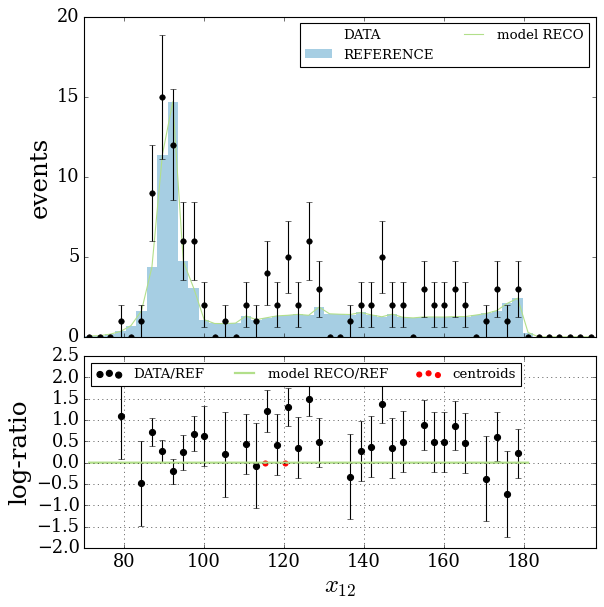

epoch: 1001, NPLM loss: -15.370584, COEFFS: 0.000000


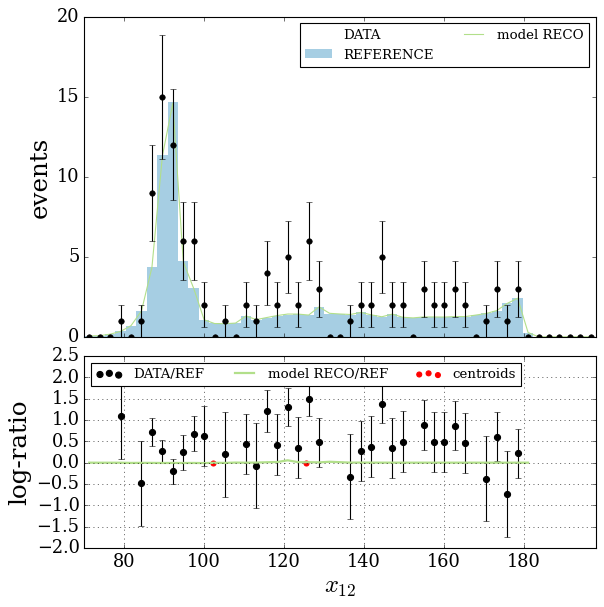

epoch: 2001, NPLM loss: -28.529368, COEFFS: 0.000000


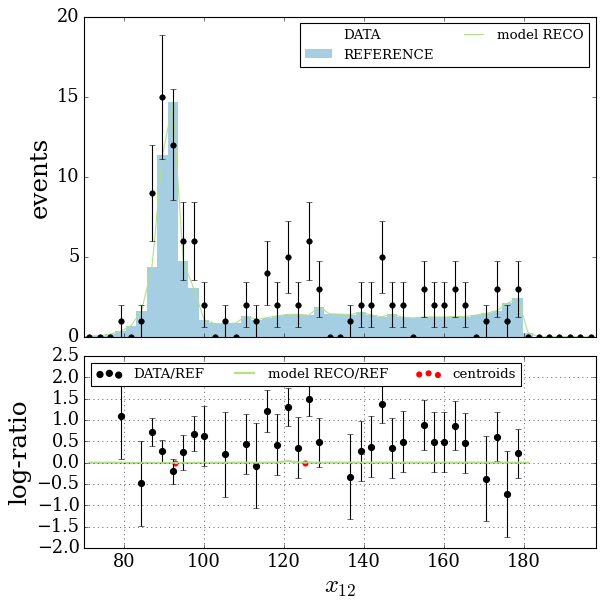

epoch: 3001, NPLM loss: -39.136649, COEFFS: 0.000000


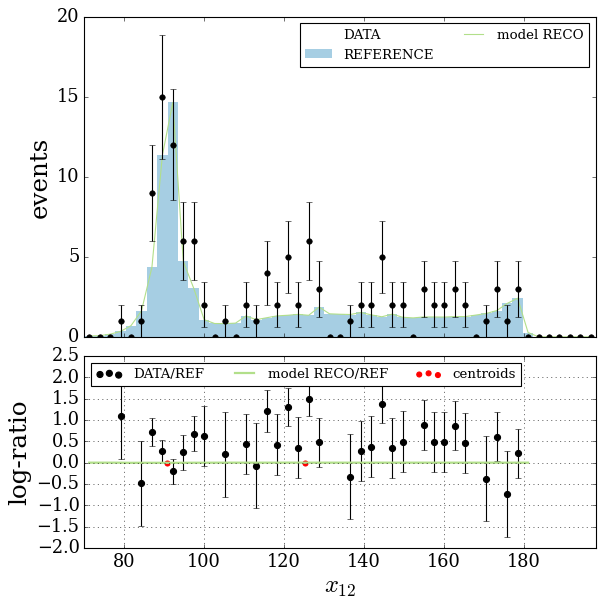

epoch: 4001, NPLM loss: -49.295806, COEFFS: 0.000000


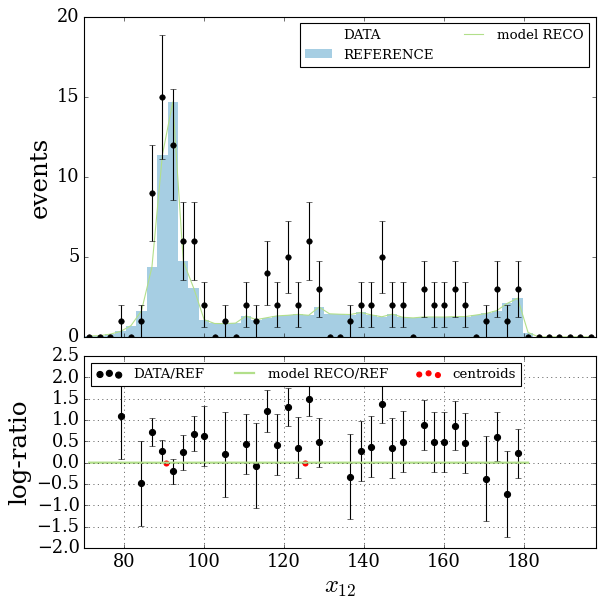

epoch: 5001, NPLM loss: -59.353312, COEFFS: 0.000000


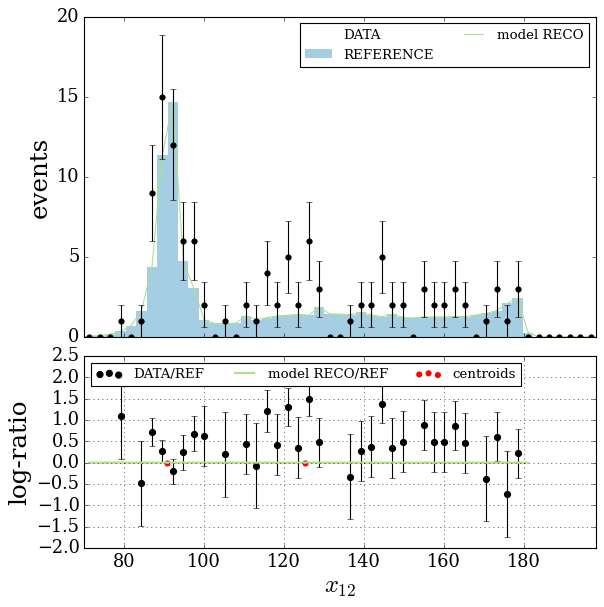

epoch: 6001, NPLM loss: -69.379008, COEFFS: 0.000000


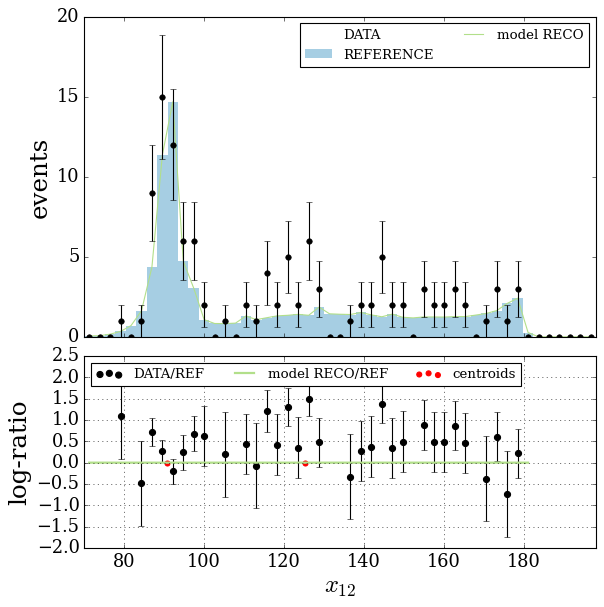

epoch: 7001, NPLM loss: -79.388339, COEFFS: 0.000000


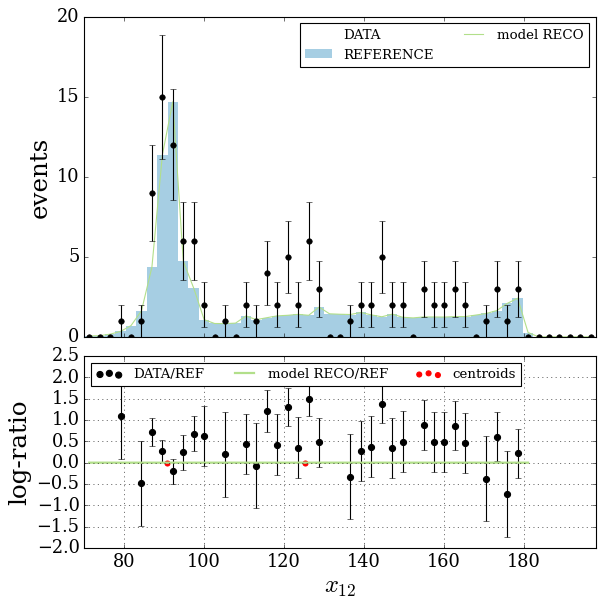

epoch: 8001, NPLM loss: -89.390654, COEFFS: 0.000000


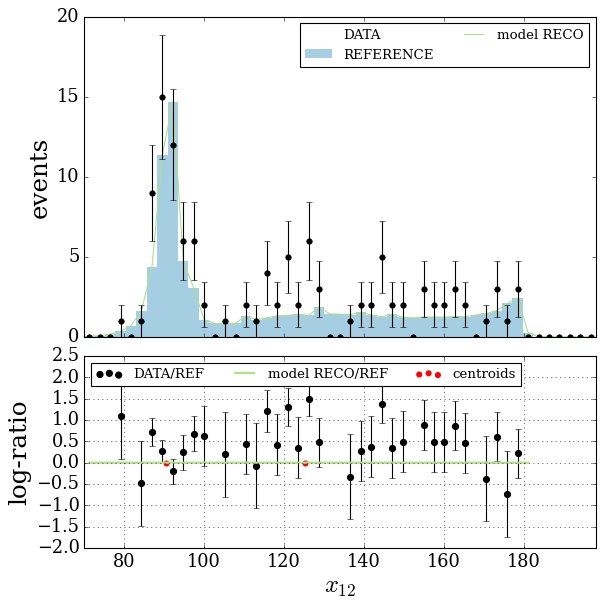

epoch: 9001, NPLM loss: -99.392010, COEFFS: 0.000000


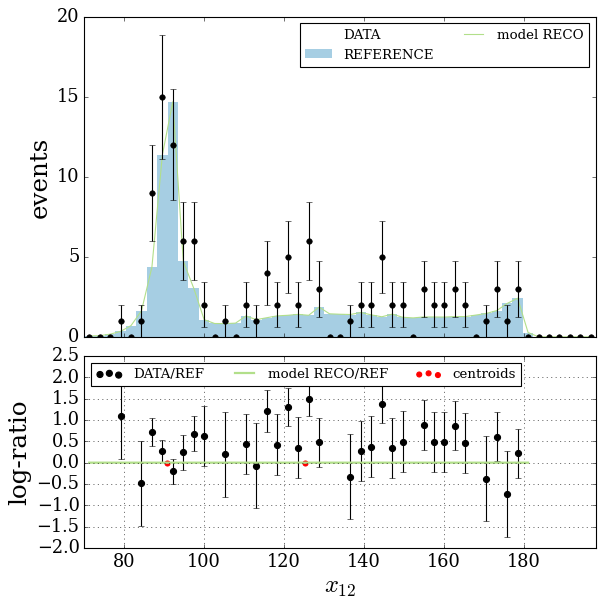

epoch: 10001, NPLM loss: -100.001848, COEFFS: 0.000000


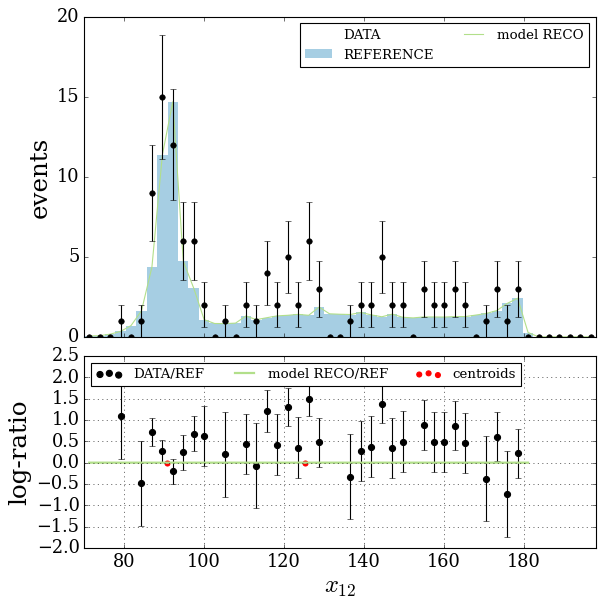

200.0038505804809

In [61]:
dutils.sparkKer(data, mc_feat, mc_labels, -1, d_weights, mc_weights)

torch.Size([112, 1]) torch.Size([132788, 1])
epoch: 1, NPLM loss: 0.000000, COEFFS: 0.000000


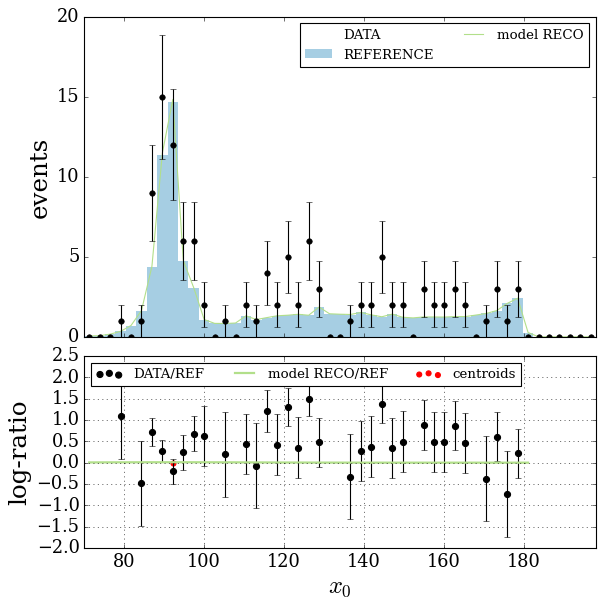

epoch: 501, NPLM loss: -1.662987, COEFFS: 0.000000


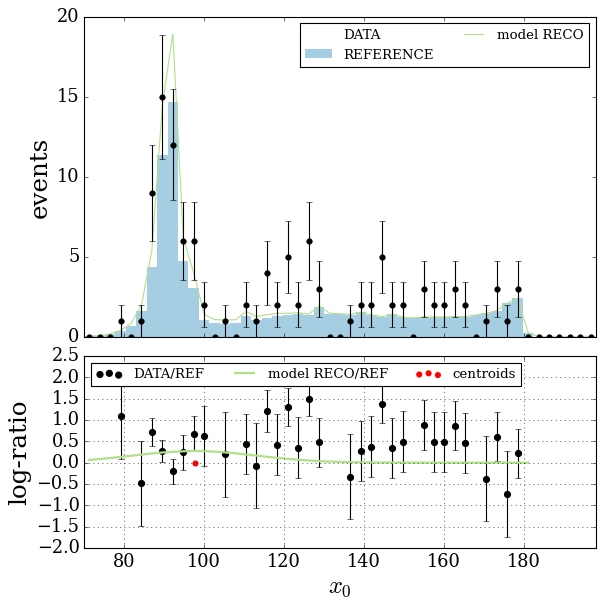

epoch: 1001, NPLM loss: -2.040308, COEFFS: 0.000000


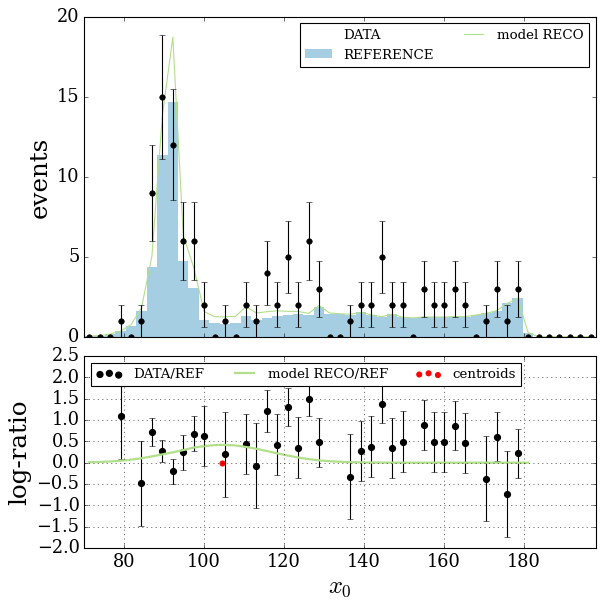

epoch: 1501, NPLM loss: -3.557315, COEFFS: 0.000000


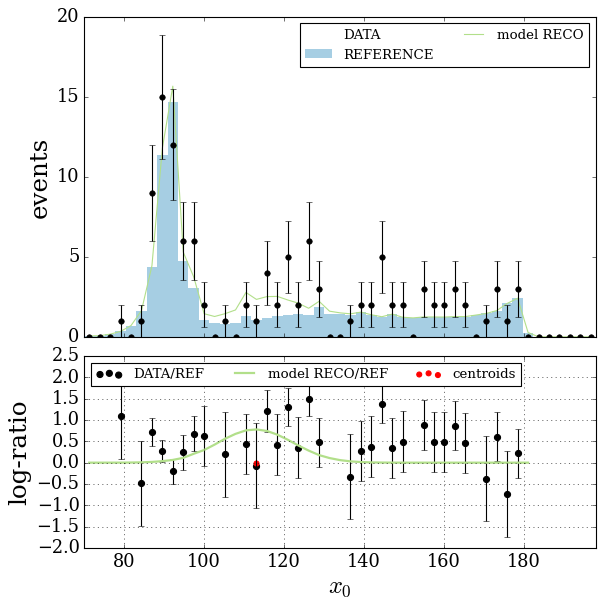

epoch: 2001, NPLM loss: -5.963679, COEFFS: 0.000000


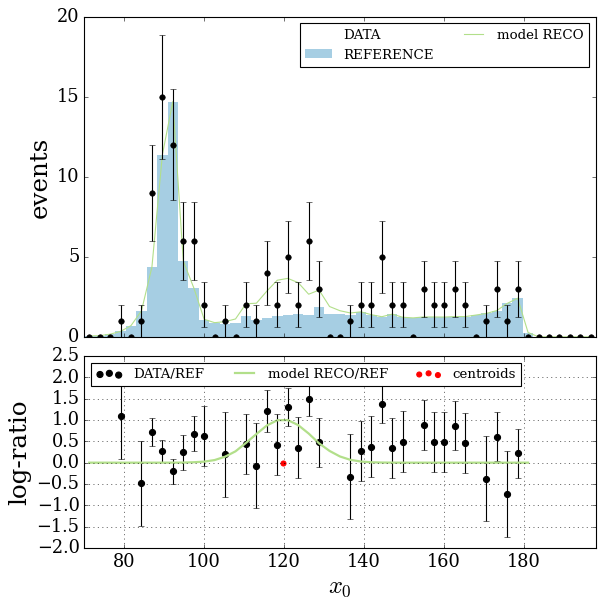

epoch: 2501, NPLM loss: -6.774211, COEFFS: 0.000000


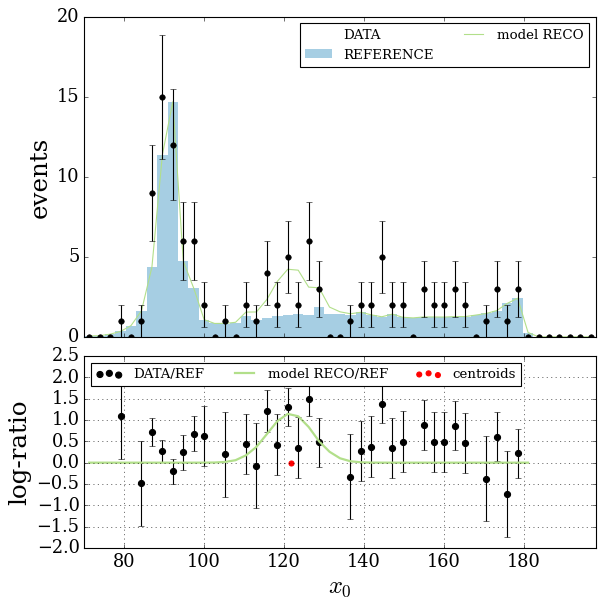

epoch: 3001, NPLM loss: -6.931000, COEFFS: 0.000000


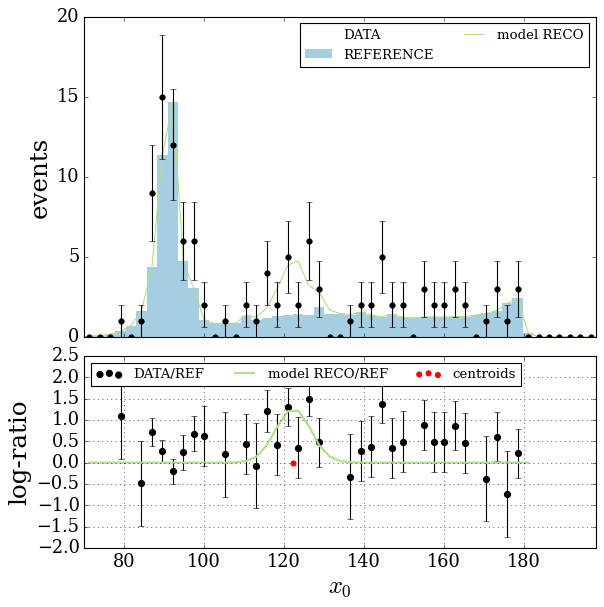

epoch: 3501, NPLM loss: -6.579879, COEFFS: 0.000000


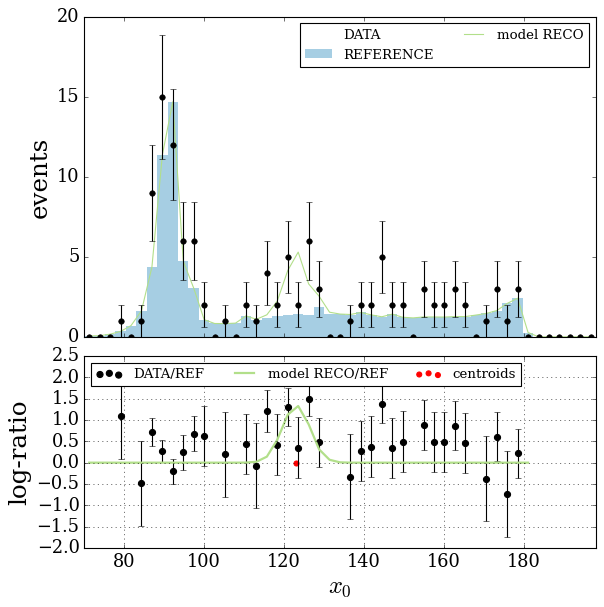

epoch: 4001, NPLM loss: -5.876258, COEFFS: 0.000000


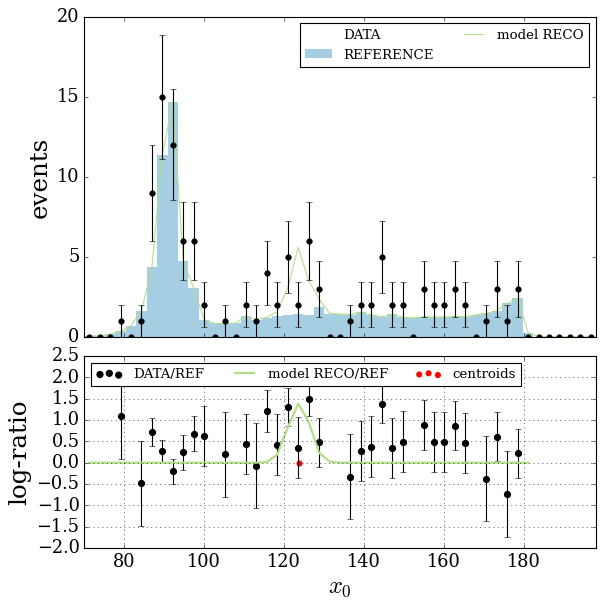

epoch: 4501, NPLM loss: -5.203508, COEFFS: 0.000000


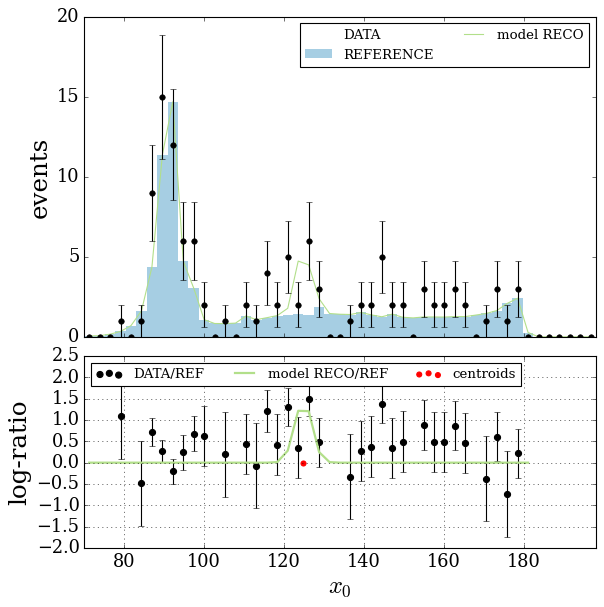

epoch: 5001, NPLM loss: -5.203600, COEFFS: 0.000000


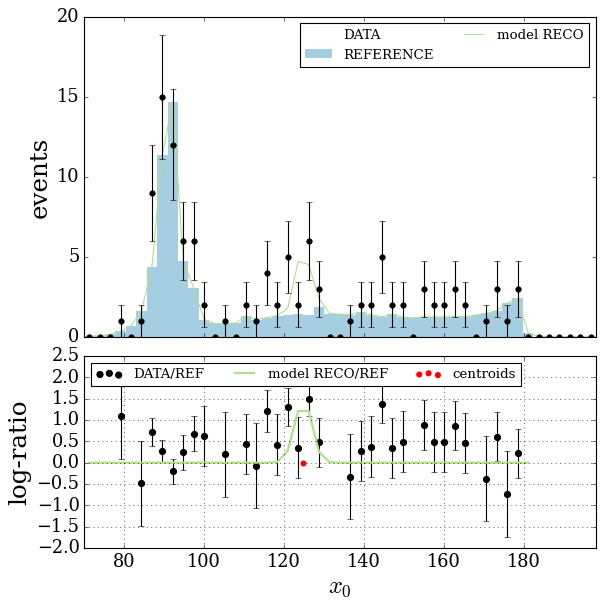

13.88786136018653

In [50]:
dutils.sparkKer(data, mc_feat, mc_labels, -1, d_weights, mc_weights)

In [ ]:
#split MCs into data and ref for fitting 
def splitInTwo(iArr,iWeight):
    print(iArr.size(0),iWeight.size(0))
    perm_sig = torch.randperm(iArr.size(0))
    half_sig = iArr.size(0) // 2
    sig1_idx = perm_sig[:half_sig]
    sig2_idx = perm_sig[half_sig:]
    return iArr[sig1_idx],iWeight[sig1_idx]*2,iArr[sig2_idx],iWeight[sig2_idx]*2

mc_data, mcw_data, mc_model, mcw_model=splitInTwo(mc,mc_weights)
sig_data,sigw_data,sig_model,sigw_model=splitInTwo(mc_sig,mc_sig_weights)

#combine all MCs together with signal and bkg labels
def combineSigMC(iSig,iSWeight,iMC,iMCWeight):
    mc_labels       = torch.zeros(iMC.shape[0],dtype=torch.float32)
    mc_sig_labels   = torch.ones(iSig.shape[0],dtype=torch.float32)
    mc_total        = torch.cat((iMC,iSig))
    mc_total_labels = torch.cat((mc_labels,mc_sig_labels))
    mc_total_weight = torch.cat((iMCWeight,iSWeight))
    return mc_total,mc_total_labels,mc_total_weight

data, data_labels, data_weights =combineSigMC(sig_data, sigw_data, mc_data,mcw_data)
model,model_labels,model_weights=combineSigMC(sig_model,sigw_model,mc_model,mcw_model

In [ ]:
lOption=2
iNToys=100
sig_idx=1
nsig=0.01
nbkg=5000
nref=40000
#def run_toy( nsig, nbkg, nref, data, labels, model, model_labels,sig_idx,data_weights=None,model_weights=None,ntoys=1000,plot=True,iOption=0):
dutils.run_toy(nsig, nbkg, nref,
               data, data_labels,model, model_labels,
               sig_idx,data_weights=data_weights,model_weights=model_weights,
               ntoys=iNToys,plot=True,iOption=lOption)


In [4]:
from scipy.stats import norm,chi2,kstest

chi2.cdf(1637,1500)

0.9926769709363542